# Creator-Trend Network Analysis

Builds a bipartite creator-to-trend structure, then projects it down to a readable trend-to-trend
network showing creator overlap between the 5 known trends. Answers two questions: (1) a
trend-to-trend network showing normalized creator overlap between each pair of trends, (2) whether
`post_owner.type` (creator/business/personal) predicts whether an account is a multi-trend
generalist or a single-trend specialist.

Full design: `CREATOR_TREND_NETWORK_STEP_BY_STEP.md`. English-only, consistent with the rest of
`code/`.

## Step 1: Build the creator-trend membership dataset

In [1]:
import pandas as pd

df1 = pd.read_csv("../data/manya_first_12012024.csv")
df2 = pd.read_csv("../data/manya_0711-1104.csv")
df3 = pd.read_csv("../data/manya_1105_1201.csv")
df4 = pd.read_csv("../data/manya_0410-0710.csv")
df_full = pd.concat([df1, df2, df3, df4], ignore_index=True)
df_full = df_full[df_full["lang"] == "en"].copy()

trend_keywords = {
    "feta_pasta": ["feta pasta", "baked feta pasta", "baked feta"],
    "sourdough": ["sourdough", "sourdough starter", "sourdough bread"],
    "banana_bread": ["banana bread", "banana bread recipe", "bananabread"],
    "baked_oats": ["baked oats", "baked oatmeal", "bakedoats"],
    "dalgona_coffee": ["dalgona coffee", "whipped coffee", "dalgona"],
}

creator_trends = {}   # username -> set of trends they posted about
creator_type = {}     # username -> post_owner.type
creator_trend_counts = {}  # (username, trend) -> number of posts in that trend

# Vectorized: loop over unique creators per trend (thousands), not every matched row
# (hundreds of thousands with duplicates) -- same output as a per-row loop, much faster.
for trend, kws in trend_keywords.items():
    pattern = "|".join(kws)
    mask = (df_full["text"].str.contains(pattern, case=False, na=False, regex=True) |
            df_full["hashtags"].str.contains(pattern, case=False, na=False, regex=True))
    d = df_full[mask]

    trend_creators = d["post_owner.username"].dropna().unique()
    type_lookup = d.drop_duplicates("post_owner.username").set_index("post_owner.username")["post_owner.type"]

    for uname in trend_creators:
        creator_trends.setdefault(uname, set()).add(trend)
    creator_type.update(type_lookup.to_dict())

    counts = d["post_owner.username"].value_counts()
    creator_trend_counts.update({(uname, trend): cnt for uname, cnt in counts.items()})

print(f"Total unique creators: {len(creator_trends)}")

Total unique creators: 31540


Design doc expects 45,163 here; the doc's own "Design decisions" section separately cites
31,540 "unique creators across the 5 trends" -- these should be the same computation (creators
matching at least one trend's keyword mask), so whichever the actual run prints, that's the real
number to trust; noting the doc's internal inconsistency here rather than assuming either figure.

## Step 2: Compute trend-level creator sets and pairwise Jaccard similarity

In [2]:
from itertools import combinations

# Which creators posted in each trend, as a set, for Jaccard computation
trend_creator_sets = {trend: set() for trend in trend_keywords}
for uname, trends in creator_trends.items():
    for t in trends:
        trend_creator_sets[t].add(uname)

for trend, creators in trend_creator_sets.items():
    print(f"{trend}: {len(creators)} unique creators")

feta_pasta: 241 unique creators
sourdough: 19368 unique creators
banana_bread: 8692 unique creators
baked_oats: 77 unique creators
dalgona_coffee: 7898 unique creators


In [3]:
jaccard_rows = []
for t1, t2 in combinations(trend_keywords.keys(), 2):
    set1, set2 = trend_creator_sets[t1], trend_creator_sets[t2]
    shared = len(set1 & set2)
    union = len(set1 | set2)
    jaccard = shared / union if union > 0 else 0
    jaccard_rows.append({"trend_1": t1, "trend_2": t2, "shared_creators": shared,
                          "union_creators": union, "jaccard_similarity": round(jaccard, 4)})

jaccard_df = pd.DataFrame(jaccard_rows).sort_values("jaccard_similarity", ascending=False)
print(jaccard_df.to_string(index=False))

     trend_1        trend_2  shared_creators  union_creators  jaccard_similarity
   sourdough   banana_bread             2718           25342              0.1073
banana_bread dalgona_coffee             1033           15557              0.0664
   sourdough dalgona_coffee             1162           26104              0.0445
banana_bread     baked_oats               66            8703              0.0076
  feta_pasta      sourdough              131           19478              0.0067
  feta_pasta   banana_bread               55            8878              0.0062
  feta_pasta dalgona_coffee               25            8114              0.0031
   sourdough     baked_oats               44           19401              0.0023
  baked_oats dalgona_coffee               16            7959              0.0020
  feta_pasta     baked_oats                0             318              0.0000


## Step 3: Build and visualize the trend-to-trend network

Both a network graph (intuitive) and a heatmap matrix (precise, exact values).

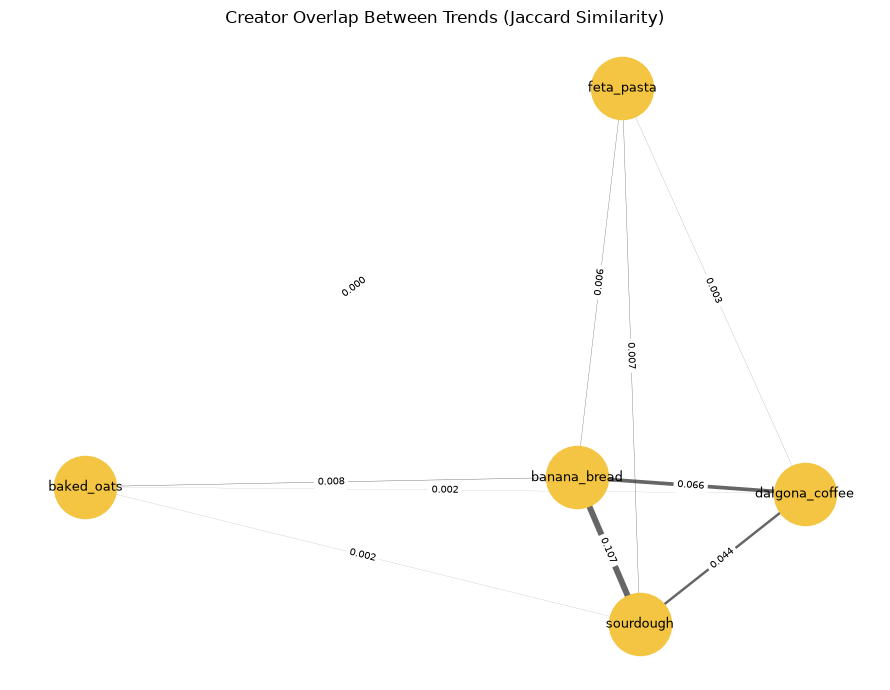

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Network graph
G = nx.Graph()
for trend in trend_keywords:
    G.add_node(trend)
for _, row in jaccard_df.iterrows():
    G.add_edge(row["trend_1"], row["trend_2"], weight=row["jaccard_similarity"])

fig, ax = plt.subplots(figsize=(9, 7))
pos = nx.spring_layout(G, seed=42, weight="weight")
weights = [G[u][v]["weight"] * 40 for u, v in G.edges()]  # scale for visibility
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="#f4c542", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6, ax=ax)
edge_labels = {(u, v): f"{G[u][v]['weight']:.3f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)
ax.set_title("Creator Overlap Between Trends (Jaccard Similarity)")
ax.axis("off")
plt.tight_layout()
plt.savefig("../output/creator_network/creator_trend_network.png", dpi=150)
plt.show()

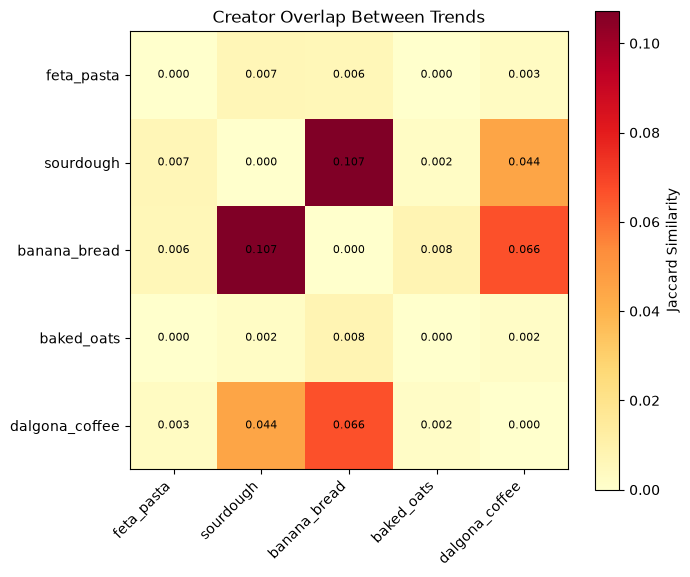

In [5]:
# Heatmap matrix, for exact values
trends_list = list(trend_keywords.keys())
matrix = pd.DataFrame(0.0, index=trends_list, columns=trends_list)
for _, row in jaccard_df.iterrows():
    matrix.loc[row["trend_1"], row["trend_2"]] = row["jaccard_similarity"]
    matrix.loc[row["trend_2"], row["trend_1"]] = row["jaccard_similarity"]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matrix.values, cmap="YlOrRd")
ax.set_xticks(range(len(trends_list)))
ax.set_yticks(range(len(trends_list)))
ax.set_xticklabels(trends_list, rotation=45, ha="right")
ax.set_yticklabels(trends_list)
for i in range(len(trends_list)):
    for j in range(len(trends_list)):
        ax.text(j, i, f"{matrix.values[i,j]:.3f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, label="Jaccard Similarity")
ax.set_title("Creator Overlap Between Trends")
plt.tight_layout()
plt.savefig("../output/creator_network/creator_trend_heatmap.png", dpi=150)
plt.show()

## Step 4: `post_owner.type` breakdown, multi-trend vs. single-trend creators

In [6]:
overlap_counts = pd.Series({k: len(v) for k, v in creator_trends.items()})
multi_trend_creators = overlap_counts[overlap_counts >= 2].index
single_trend_creators = overlap_counts[overlap_counts == 1].index

multi_types = pd.Series([creator_type[c] for c in multi_trend_creators]).value_counts(normalize=True)
single_types = pd.Series([creator_type[c] for c in single_trend_creators]).value_counts(normalize=True)

print(f"Multi-trend creators (n={len(multi_trend_creators)}):")
print((multi_types * 100).round(1))
print(f"\nSingle-trend creators (n={len(single_trend_creators)}):")
print((single_types * 100).round(1))

Multi-trend creators (n=4232):
creator     61.9
business    36.2
personal     1.8
Name: proportion, dtype: float64

Single-trend creators (n=27308):
creator     58.8
business    36.5
personal     4.7
Name: proportion, dtype: float64


## Step 4.5: `post_owner.type` breakdown, per node AND per edge

Extends Step 4: creator type composition within each individual trend (node-level) and within
each pair's shared creators specifically (edge-level).

In [7]:
# Node-level: creator type composition WITHIN each trend
node_type_rows = []
for trend, creators in trend_creator_sets.items():
    types = pd.Series([creator_type[c] for c in creators]).value_counts(normalize=True)
    for otype, pct in types.items():
        node_type_rows.append({"trend": trend, "type": otype, "pct": round(pct * 100, 1)})
node_type_df = pd.DataFrame(node_type_rows)
print(node_type_df.to_string(index=False))

# Edge-level: creator type composition among SHARED creators only (the overlap set)
edge_type_rows = []
for t1, t2 in combinations(trend_keywords.keys(), 2):
    shared = trend_creator_sets[t1] & trend_creator_sets[t2]
    if len(shared) == 0:
        continue
    types = pd.Series([creator_type[c] for c in shared]).value_counts(normalize=True)
    for otype, pct in types.items():
        edge_type_rows.append({"pair": f"{t1}-{t2}", "n_shared": len(shared),
                                "type": otype, "pct": round(pct * 100, 1)})
edge_type_df = pd.DataFrame(edge_type_rows)
print(edge_type_df.to_string(index=False))

         trend     type  pct
    feta_pasta  creator 55.2
    feta_pasta business 42.3
    feta_pasta personal  2.5
     sourdough  creator 55.2
     sourdough business 40.0
     sourdough personal  4.8
  banana_bread  creator 63.3
  banana_bread business 33.6
  banana_bread personal  3.0
    baked_oats  creator 66.2
    baked_oats business 32.5
    baked_oats personal  1.3
dalgona_coffee  creator 66.2
dalgona_coffee business 30.6
dalgona_coffee personal  3.2
                       pair  n_shared     type  pct
       feta_pasta-sourdough       131  creator 57.3
       feta_pasta-sourdough       131 business 41.2
       feta_pasta-sourdough       131 personal  1.5
    feta_pasta-banana_bread        55  creator 52.7
    feta_pasta-banana_bread        55 business 43.6
    feta_pasta-banana_bread        55 personal  3.6
  feta_pasta-dalgona_coffee        25 business 52.0
  feta_pasta-dalgona_coffee        25  creator 48.0
     sourdough-banana_bread      2718  creator 61.6
     sourdough-b

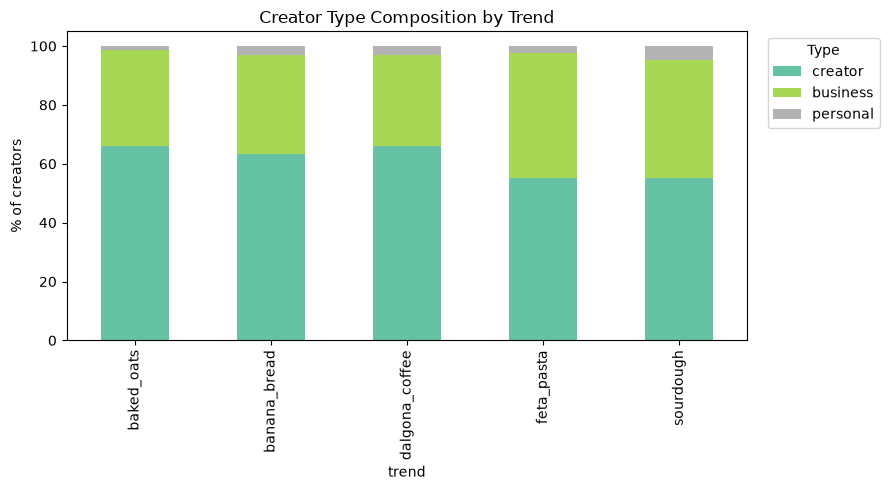

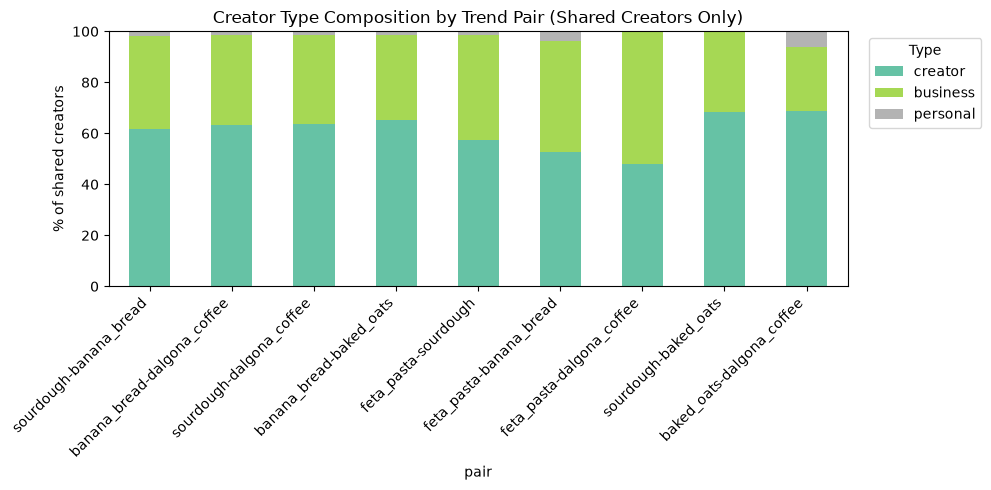

In [8]:
# Node-level stacked bar
node_pivot = node_type_df.pivot(index="trend", columns="type", values="pct").fillna(0)
node_pivot = node_pivot[["creator", "business", "personal"]]  # consistent stacking order
node_pivot.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="Set2")
plt.ylabel("% of creators")
plt.title("Creator Type Composition by Trend")
plt.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../output/_unused/creator_type_by_node.png", dpi=150)
plt.show()

# Edge-level stacked bar, ordered by Jaccard similarity so strongest connections group together
edge_pivot = edge_type_df.pivot(index="pair", columns="type", values="pct").fillna(0)
edge_pivot = edge_pivot[["creator", "business", "personal"]]
pair_order = [f"{row.trend_1}-{row.trend_2}" for row in jaccard_df.itertuples()
              if f"{row.trend_1}-{row.trend_2}" in edge_pivot.index]
edge_pivot = edge_pivot.loc[pair_order]
edge_pivot.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="Set2")
plt.ylabel("% of shared creators")
plt.title("Creator Type Composition by Trend Pair (Shared Creators Only)")
plt.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../output/_unused/creator_type_by_edge.png", dpi=150)
plt.show()

## Step 5 (optional secondary view): creators in 3+ trends

Just a count check -- only build the full bipartite graph if this count is small enough to
visualize clearly.

In [9]:
heavy_overlap_creators = overlap_counts[overlap_counts >= 3].index
print(f"Creators in 3+ trends: {len(heavy_overlap_creators)}")
print(overlap_counts[overlap_counts >= 3].value_counts().sort_index())

Creators in 3+ trends: 494
3    484
4     10
Name: count, dtype: int64


## Step 6: Save outputs

In [10]:
jaccard_df.to_csv("../output/cleaned_data/trend_creator_overlap.csv", index=False)
print("Saved trend_creator_overlap.csv")

Saved trend_creator_overlap.csv
